In [2]:
import Pkg;
Pkg.activate(@__DIR__);
Pkg.instantiate()

  Activating environment at `~/Git/cartpole/Controller/TinyMPC/Project.toml`


In [532]:
using LinearAlgebra
using ForwardDiff
using Plots
using Random
using Printf
using MeshCat
using TrajOptPlots
using RobotZoo:Cartpole
using RobotDynamics
using StaticArrays
using GeometryTypes
# using ColorTypes

In [533]:
vis = Visualizer()
model = Cartpole()
TrajOptPlots.set_mesh!(vis, model)

┌ Info: MeshCat server started. You can open the visualizer by visiting the following URL in your browser:
│ http://127.0.0.1:8702
└ @ MeshCat /home/sam/.julia/packages/MeshCat/GlCMx/src/visualizer.jl:73


MeshCat Visualizer with path /meshcat/robot/cart/pole at http://127.0.0.1:8702

In [534]:
# Cartpole params
m1 = 1.0
m2 = 0.2
ℓ = 0.5

g = 9.81

h = 1/100

0.01

In [584]:
# x = [x, v, θ, θdot]

function cartpole_dynamics(x,u)
  r = x[1] # cart position
  θ = x[2] # pole angle
  ṙ = x[3] # change in cart position
  θ̇ = x[4] # change in pole angle

  # F = u
  # F = 0

  # ẍ = [-ℓ*(F + (θ̇ ^2)*m2*ℓ*sin(θ))/(-ℓ*(m1+m2) + m2*ℓ*cos(θ)^2) + (-g*m2*ℓ*cos(θ)*sin(θ))/(-ℓ*(m1+m2)+m2*ℓ*cos(θ)^2);
  #       ((F + θ̇ *m2*ℓ*sin(θ))*cos(θ))/(-ℓ*(m1+m2) + m2*ℓ*cos(θ)^2) + (-g*(-m1-m2)*sin(θ))/(-ℓ*(m1+m2) + m2*ℓ*cos(θ)^2)]

  # a = [cos(θ) ℓ; (m1+m2) m2*ℓ*cos(θ)]
  # b = [-g*sin(θ); F + m2*ℓ*(θ̇ ^2)*sin(θ)]
  # ẍ = a^(-1) * b

  # r̈ = ẍ[1]
  # θ̈ = ẍ[2]

  # r̈ = 1/(m1 + m2*sin(θ)^2) * (F + m2*sin(θ)*(ℓ*(θ̇ ^2) + g*cos(θ)))
  # θ̈ = 1/(ℓ*(m1 + m2*sin(θ)^2)) * (-F*cos(θ) - m2*ℓ*(θ̇ ^2)*cos(θ)*sin(θ) - (m1 + m2)*g*sin(θ))
  
  # H = np.array([[mass_cart+mass_pole, mass_pole*length_pole*c],
  #   [mass_pole*length_pole*c, mass_pole*length_pole*length_pole]])
  # C = np.array([[0, -mass_pole*qd[1]*length_pole*s],
  #   [0, 0]])
  # G = np.array([0, mass_pole*g*length_pole*s])
  # B = np.array([1, 0])

  # qdd = -np.linalg.solve(H, C@qd + G - B*u[0])

  # H = [(m1+m2) m2+ℓ*cos(θ); m2*ℓ*cos(θ) m2*ℓ^2]
  # C = [0 -m2*θ*ℓ*sin(θ); 0 0]
  # G = [0, m2*g*ℓ*sin(θ)]
  # B = [1, 0]
  # ẍ = -H\(C*[ṙ θ̇ ]' + G - B*u)
  
  # r̈ = ẍ[1]
  # θ̈ = ẍ[2]

  

  return [ṙ; θ̇; r̈; θ̈ ]
end
function cartpole_rk4(x,u)
  #RK4 integration with zero-order hold on u
  # f1 = cartpole_dynamics(x, u)
  # f2 = cartpole_dynamics(x + 0.5*h*f1, u)
  # f3 = cartpole_dynamics(x + 0.5*h*f2, u)
  # f4 = cartpole_dynamics(x + h*f3, u)
  f1 = dynamics(model, x, u)
  f2 = dynamics(model, x + 0.5*h*f1, u)
  f3 = dynamics(model, x + 0.5*h*f2, u)
  f4 = dynamics(model, x + h*f3, u)
  xn = x + (h/6.0)*(f1 + 2*f2 + 2*f3 + f4)
  return xn
end

cartpole_rk4 (generic function with 1 method)

In [585]:
rg = 0
θg = 0
vg = 0
θ̇g = 0
xg = [rg; θg; vg; θ̇g];

In [586]:
# Linearize dynamics about vertical
A = ForwardDiff.jacobian(x->cartpole_rk4(x, 0), [0; pi; 0; 0]);
B = ForwardDiff.derivative(u->cartpole_rk4([0; pi; 0; 0], u), 0);
B = reshape(B, (4,1));

In [587]:
display(A)
display(B)

4×4 Matrix{Float64}:
 1.0  9.81192e-5  0.01  3.27e-7
 0.0  1.00118     0.0   0.0100039
 0.0  0.0196277   1.0   9.81192e-5
 0.0  0.235532    0.0   1.00118

4×1 reshape(::SVector{4, Float64}, 4, 1) with eltype Float64:
 5.000163500000001e-5
 0.00010001962000000001
 0.010000654
 0.020007848

In [588]:
Tfinal = 5.0            # final time
N = Int(Tfinal/h)+1     # number of time steps
t_vec = h*(0:N-1)

nx = 4
nu = 1

# Cost weights
Q = Array(Diagonal([1; 1; 1; 1]));
R = 1
Qf = 1*Q;

# Penalty
ρ = 0.1
R̃ = [R + ρ*I]

# Precompute
cache = (
    Ã = A,
    B̃ = B,
    Kinf = zeros(nu,nx),
    Pinf = zeros(nx,nx),
    Quu_inv = zeros(nu,nu),
    AmBKt = zeros(nx,nx), 
    coeff_d2p = zeros(nx,nu), 
)

K = [zeros(nu,nx) for i = 1:N-1]; # Feedback gain
P = [zeros(nx,nx) for i = 1:N];   # Cost to go quadratic term
P[N] = Qf


for k = (N-1):-1:1
    K[k] = (R̃ + B'*P[k+1]*B)\(B'*P[k+1]*A);
    P[k] = Q + A'*P[k+1]*(A - B*K[k]);
end

cache.Kinf .= K[1];
cache.Pinf .= P[1];
cache.Quu_inv .= (R̃ + cache.B̃'*cache.Pinf*cache.B̃);
cache.AmBKt .= (cache.Ã - cache.B̃*cache.Kinf)';
cache.coeff_d2p .= cache.Kinf'*R̃ - cache.AmBKt*cache.Pinf*cache.B̃;


# Create trajectory to follow
Xref = [xg for i = 1:N]
Uref = [zeros(nu) for i = 1:N-1]

# u_min = 0.1*[1; 1; 1; 1] - uhover
# u_max =  uhover - 0.1*[1; 1; 1; 1] 
u_min = -5
u_max = 5
;

In [589]:
N = 1000
K = [zeros(nu,nx) for i = 1:N-1]; # Feedback gain
P = [zeros(nx,nx) for i = 1:N];   # Cost to go quadratic term
P[N] = Qf
for k = (N-1):-1:1
    K[k] = (R̃ + B'*P[k+1]*B)\(B'*P[k+1]*A);
    P[k] = Q + A'*P[k+1]*(A - B*K[k]);
end

In [595]:
K
cache.Kinf .= K[1]

1×4 Matrix{Float64}:
 -0.900605  30.8552  -2.07725  6.57798

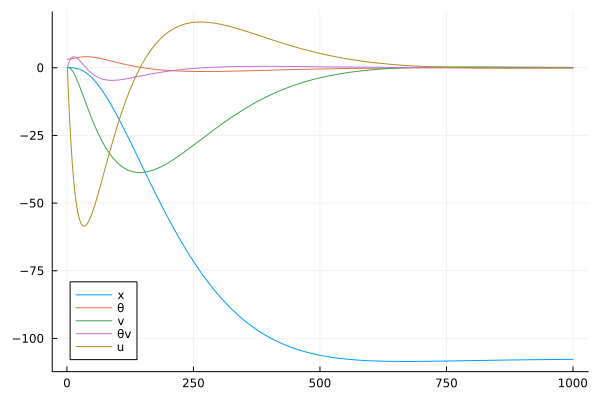

In [597]:
Nl = 1000
x = [zeros(nx) for i = 1:Nl]
x[1] = [0; pi; 0; 0]
u = [zeros(nu) for i = 1:Nl-1]

for k = 1:Nl-1
    u[k] = -cache.Kinf*(x[k]-[0;pi;0;0])
    x[k+1] = A*x[k] + B*u[k]
    # x[k+1] = dynamics(model, x[k], u[k])
end

plot(hcat(x...)', label=["x" "θ" "v" "θv"])
plot!(hcat(u...)', label="u")

In [600]:
x[end]
cache.Kinf

1×4 Matrix{Float64}:
 -0.900605  30.8552  -2.07725  6.57798

In [ ]:
X1 = [SVector{4}(x_) for x_ in x];
visualize!(vis, model, 1.0:h:Nl*h, X1)

In [399]:
include("TinyMPC.jl")


x = [zeros(nx) for i = 1:N]
# x[1] = X̃ref[k]
# x[1] = Xref[1]
x[1] .= [0; pi; 0; 0]
u = [zeros(nu) for i = 1:N-1]

z = [zeros(nu) for i = 1:N-1]
znew = [zeros(nu) for i = 1:N-1]
y = [zeros(nu) for i = 1:N-1]

q = [zeros(nx) for i = 1:N];
r = [zeros(nu) for i = 1:N-1];

p = [zeros(nx) for i = 1:N];      # cost to go linear term
p[N] = q[N];

d = [zeros(nu) for i = 1:N-1];    # feedforward control

params = (
    Q = Q, R = R, Qf = Qf,
    umin = u_min, umax = u_max,
    Xref = Xref, Uref = Uref, 
    # Xref = Xref[k:k+Nh-1], Uref = Uref[k:k+Nh-2], 
    cache = cache
);

# Solve
Δu = 0
Δu, status, iter = solve_admm!(vis, params, q, r, p, d, x, u, z, znew, y; ρ=ρ, abs_tol=1e-2, max_iter=200)

([[-69.42799553704887], [-65.41268310485694], [-61.64140635921002], [-58.09935148802528], [-54.77260381104699], [-51.64809320751907], [-48.71354285536529], [-45.95742108091428], [-43.36889613040614], [-40.937793685958155]  …  [-4.0305848556488115], [-3.956808743477623], [-3.866203822508936], [-3.75689461057425], [-3.6268204203752816], [-3.473718191340339], [-3.2951037762496753], [-3.0882515456986965], [-2.8501721614354096], [-2.5775883565251547]], 0, 201)

In [278]:
@show iter
Δu
;

iter = 1


In [343]:
t_vec

0.0:0.01:5.0

In [467]:
X1 = [SVector{4}(x_) for x_ in x];
visualize!(vis, model, t_vec, X1)

# Nl = 50000
# t_vec_2 = 0.0:h:Nl*h
# xhist = [zeros(4) for i = 1:Nl]
# xhist[1] = [0; pi; 0; 0]
# for k = 1:Nl-1
#     xhist[k+1] = cartpole_rk4(xhist[k], 0)
#     if k % Nl/10 == 0
#         display(xhist[k+1])
#     end
# end
# X1 = [SVector{4}(x_) for x_ in xhist];
# visualize!(vis, model, t_vec_2[Nl], X1)

MethodError: MethodError: no method matching get_model(::Cartpole{Float64})
Closest candidates are:
  get_model(!Matched::TrajectoryOptimization.Problem) at /home/sam/.julia/packages/TrajectoryOptimization/zuW7S/src/problem.jl:230
  get_model(!Matched::TrajectoryOptimization.TrajOptNLP) at /home/sam/.julia/packages/TrajectoryOptimization/zuW7S/src/nlp.jl:511

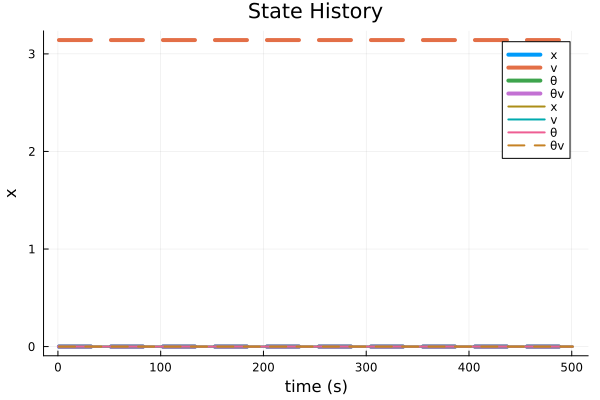

In [261]:
Xsim_m = hcat(x...)
Usim_m = hcat(Δu...)
Xref_m = hcat(Xref...)
plot(Xref_m',label=["x" "v" "θ" "θv"],
linestyle=[:dash :dash :dash], linewidth=[4 4 4])

display(plot!(Xsim_m',label=["x" "v" "θ" "θv"],
linestyle=[:solid :solid :solid :dash :dash :dash :dash], linewidth=[2 2 2 2 2 2 2],
            title="State History", xlabel="time (s)", ylabel="x"))